### Multi Tool Integration

In [6]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [7]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [9]:
# Wikipedia

from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [10]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation me'

In [11]:
from dotenv import load_dotenv
load_dotenv()

True

In [12]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\IT SOLUTIONS\AppData\Local\Temp\ipykernel_23396\735679136.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [13]:
tavily.invoke("Provide me the recent AI news for march 3rd 2025")

[{'title': 'Weekly AI News: 3 March 2025 - AIforBusiness.net',
  'url': 'https://www.linkedin.com/pulse/weekly-ai-news-3-march-2025-aiforbusinessnet-johan-steyn-qrumf',
  'content': 'A thought-provoking analysis in the Daily Maverick questions AI’s growing influence, warning that biases within AI systems could shape decision-making in unpredictable ways. As AI becomes more embedded in hiring, finance, and governance, are we truly in control?\n\nGoogle’s decision to ease restrictions on AI use for military and surveillance purposes has ignited debate over the ethical boundaries of AI deployment. Should corporations define these limits, or should governments step in?\n\nFinally, AI is transforming the factory floor, optimising production lines and supply chains. With automation accelerating, AI’s impact on physical industries is becoming just as significant as its role in digital transformation. Stay tuned for next week’s AI roundup! [...] ### Johan Steyn\n\nSubscribe to our newsletter: 

In [14]:
# adding in tools

tools= [arxiv,wiki,tavily]

In [15]:
# initialize the model and bind the tools

from langchain_openai import ChatOpenAI
llm= ChatOpenAI(model="gpt-4o")
llm_with_tools=llm.bind_tools(tools)
llm_with_tools

RunnableBinding(bound=ChatOpenAI(output_version=None, profile={'name': 'GPT-4o', 'release_date': '2024-05-13', 'last_updated': '2024-08-06', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000021C81BE9F10>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000021C82418980>, root_client=<openai.OpenAI object at 0x0000021C8152BA40>, root_async_client=<openai.AsyncOpenAI object at 0x0000021C823134D0>, model_name='gpt-4o', model

In [ ]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

In [16]:
# State schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]

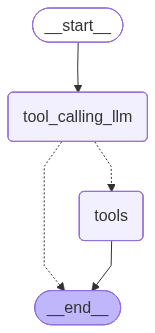

In [ ]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()



In [22]:
from langchain_core.messages import HumanMessage
messages=graph.invoke({"messages":HumanMessage(content="what is islam")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is islam
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_1JUOgg8ZAfg8zBEdR9JWyqlD)
 Call ID: call_1JUOgg8ZAfg8zBEdR9JWyqlD
  Args:
    query: Islam
================================= Tool Message =================================
Name: wikipedia

Page: Islam
Summary: Islam is an Abrahamic monotheistic religion based on the Quran and the teachings of Muhammad. The religion's adherents, called Muslims, are estimated to number 2 billion worldwide and are the world's second-largest religious population after Christians.

 
Muslims believe that there is a primordial faith that was revealed many times through earlier prophets and messengers, including Adam, Noah, Abraham, Moses, and Jesus, and they believe that Islam is the universal and compl
